# Go/No-Go 1 reproducibility notebook
This notebook reads the frozen outputs, reproduces the current decision table, and visualizes the STEP/B-Rep calibration. Run it from the `go_nogo1` directory.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
root = Path.cwd()
assert (root / 'results').exists(), 'Run with cwd set to go_nogo1'
inventory = json.loads((root/'results/urdf_inventory.summary.json').read_text())
entities = json.loads((root/'results/robot_entities.summary.json').read_text())
audit = json.loads((root/'results/audit30/audit30_summary.json').read_text())
robust = json.loads((root/'results/robustness/remesh_summary.json').read_text())
brep = json.loads((root/'results/brep/brep_summary.json').read_text())

In [2]:
checks = pd.DataFrame([
 {'check':'Eligible robot entities','value':entities['eligible_entities'],'threshold':'>=24','pass':entities['eligible_entities']>=24},
 {'check':'Maximum Audit-30 source share','value':audit['max_source_share'],'threshold':'<=0.50','pass':audit['max_source_share']<=.5},
 {'check':'Remesh rank rho (50%)','value':robust['rank_rho_original_vs_50pct'],'threshold':'>=0.85','pass':robust['rank_rho_original_vs_50pct']>=.85},
 {'check':'Remesh rank rho (25%)','value':robust['rank_rho_original_vs_25pct'],'threshold':'>=0.85','pass':robust['rank_rho_original_vs_25pct']>=.85},
 {'check':'Triangle-count |rho|','value':abs(robust['triangle_count_rho_full_pool']),'threshold':'<0.30','pass':abs(robust['triangle_count_rho_full_pool'])<.30},
 {'check':'Mesh-BRep rho (independent)','value':brep['mesh_brep_spearman_rho'],'threshold':'>=0.50','pass':brep['mesh_brep_spearman_rho']>=.5},
 {'check':'Mesh-BRep rho (same geometry)','value':brep['same_geometry_mesh_brep_spearman_rho'],'threshold':'>=0.50','pass':brep['same_geometry_mesh_brep_spearman_rho']>=.5},
])
checks

,check,value,threshold,pass
0,Eligible robot entities,142.000000,>=24,True
1,Maximum Audit-30 source share,0.300000,<=0.50,True
2,Remesh rank rho (50%),0.875493,>=0.85,True
3,Remesh rank rho (25%),0.893110,>=0.85,True
4,Triangle-count |rho|,0.067806,<0.30,True
5,Mesh-BRep rho (independent),-0.050000,>=0.50,False
6,Mesh-BRep rho (same geometry),0.200000,>=0.50,False


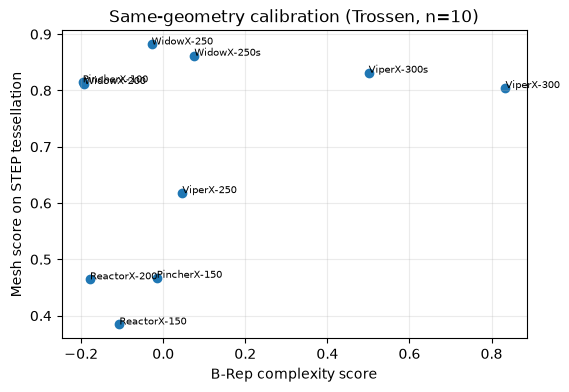

In [3]:
pairs = pd.read_csv(root/'results/brep/mesh_brep_pairs.csv')
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(pairs.brep_complexity_score, pairs.same_geometry_mesh_score)
for row in pairs.itertuples(): ax.annotate(row.dataset_name, (row.brep_complexity_score, row.same_geometry_mesh_score), fontsize=7)
ax.set(xlabel='B-Rep complexity score', ylabel='Mesh score on STEP tessellation', title='Same-geometry calibration (Trossen, n=10)')
ax.grid(alpha=.25)
plt.show()

## Current interpretation
The candidate-pool, diversity, remeshing, and triangle-confounding checks pass. Both B-Rep checks fail. Expert agreement and Mesh-human validity remain unavailable until at least two completed blinded rating files are provided.